# Assignment 2: The "Smart Labeling Pipeline" Challenge

**Total Marks: 20**

Build a cost-effective, high-quality labeling pipeline using human annotation, programmatic rules, and LLMs.

This notebook implements an end-to-end smart labeling pipeline to:
1. Establish gold standard through human annotation and measure inter-annotator agreement (6 marks)
2. Label data programmatically using weak supervision (Snorkel) (6 marks)
3. Optimize labeling budget using active learning (5 marks)
4. Leverage LLMs for bulk labeling and detect hallucinations (e.g. noisy labels) (3 marks)

## Setup and Imports

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from snorkel.labeling import labeling_function, PandasLFApplier, LFAnalysis
from snorkel.labeling.model import LabelModel
from statsmodels.stats.inter_rater import fleiss_kappa
import google.generativeai as genai
import time
from pathlib import Path
import re
from collections import Counter

Matplotlib is building the font cache; this may take a moment.
c:\Acads\STTAI_assignment 2\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\kalep\AppData\Local\Temp\ipykernel_13668\2686275648.py:13: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


## Task 1: The Human as Annotator (6 Marks)

**Objective:** Establish a "Gold Standard" dataset and measure human consensus.

### Part 1.1: Parse Annotator CSV Files

After annotating the first 100 reviews, export annotations from three annotators (A, B, C) as CSV files.
Parse these CSV files into clean DataFrames for analysis.

In [2]:
def parse_annotator_csv(csv_path):
    """
    Parses annotator CSV file into a clean DataFrame.
    
    Args:
        csv_path (str): Path to annotator CSV file
        
    Returns:
        pd.DataFrame: DataFrame with columns ['review_id', 'review', 'label']
                     where label is one of: 'Positive', 'Negative', 'Neutral'
    
    Note:
        - Look for relevant column names in the CSV file
        - If column names differ, the function will try to map them appropriately
        - Finally, return with two columns 'review' and 'label'
    """
    # Read the CSV file
    df = pd.read_csv(csv_path)
    
    # Map column names to standard names
    column_name = {}
    
    # Map review_id
    if 'id' in df.columns:
        column_name['id'] = 'review_id'
    
    # Map sentiment to label
    if 'sentiment' in df.columns:
        column_name['sentiment'] = 'label'
    
    df = df.rename(columns=column_name)
    
    # Keep only the required columns
    df = df[['review_id', 'review', 'label']]
    
    return df

In [3]:
# Parse CSV files
# csv_base_path = Path(r"c:\Users\kalep\OneDrive\STTAI\Smart_Labelling")
csv_base_path = Path("./data")

df_a = parse_annotator_csv(csv_base_path / "annotator_a.csv")
df_b = parse_annotator_csv(csv_base_path / "annotator_b.csv")
df_c = parse_annotator_csv(csv_base_path / "annotator_c.csv")

# Display sample data
print("Annotator A - First 5 rows:")
print(df_a.head())
print("\n")

print("Annotator B - First 5 rows:")
print(df_b.head())
print("\n")

print("Annotator C - First 5 rows:")
print(df_c.head())
print("\n")
print(df_a.columns)
print(df_a.head())


Annotator A - First 5 rows:
   review_id                                             review     label
0          1  This movie is a triumph in every sense. Highly...  Positive
1          2  I have never been so bored in my life. The sco...  Negative
2          3  I was completely blown away by this film. The ...  Positive
3          4  The trailer was better than the movie. The act...  Negative
4          5  Middle of the road entertainment. Visually it'...  Negative


Annotator B - First 5 rows:
   review_id                                             review     label
0          1  This movie is a triumph in every sense. Highly...  Positive
1          2  I have never been so bored in my life. The sco...  Negative
2          3  I was completely blown away by this film. The ...  Positive
3          4  The trailer was better than the movie. The act...  Negative
4          5  Middle of the road entertainment. Visually it'...   Neutral


Annotator C - First 5 rows:
   review_id            

### Part 1.2: Implement Fleiss' Kappa from Scratch

Measure inter-annotator agreement using Fleiss' Kappa statistic.
Implement the formula from scratch and compare with statsmodels implementation.

In [4]:
def fleiss_kappa_scratch(rating_matrix):
    """
    Computes Fleiss' Kappa for multiple raters from scratch.
    
    Args:
        rating_matrix (np.array): A Count Matrix of shape (N, k).
                                  - N = number of items (rows)
                                  - k = number of categories (columns)
                                  - Element [i, j] = Count of raters who assigned category j to item i.
                                  Example: 
                                    [[0, 0, 3],   # Item 0: All 3 raters said Category 2
                                     [1, 2, 0]]   # Item 1: 1 rater said Cat 0, 2 said Cat 1
                            
    
    Returns:
        float: Kappa score (ranges from -1 to 1, where 1 = perfect agreement)
    
    Formula:
        κ = (P_bar - P_e_bar) / (1 - P_e_bar)
        
        where:
        - P_bar = (1/N) * Σ(P_i) = average proportion of agreement across all items
        - P_i = (1/(n*(n-1))) * Σ(k_ij * (k_ij - 1)) for item i
        - P_e_bar = Σ(p_j^2) = expected agreement by chance
        - p_j = proportion of all assignments to category j
    
    Note:
        - N = number of items (samples)
        - n = number of raters per item (should be constant)
        - k_ij = number of raters who assigned category j to item i
    """
    rating_matrix = np.asarray(rating_matrix, dtype=float)
    
    N = rating_matrix.shape[0] 
    k = rating_matrix.shape[1]  
    n = rating_matrix.sum(axis=1)[0] 

    p_i = np.sum(rating_matrix * (rating_matrix - 1), axis=1) / (n * (n - 1))

    P_bar = np.mean(p_i)

    total_assignments = rating_matrix.sum()
    p_j = rating_matrix.sum(axis=0) / total_assignments

    P_e_bar = np.sum(p_j ** 2)

    if P_e_bar == 1:
        kappa = 0  
    else:
        kappa = (P_bar - P_e_bar) / (1 - P_e_bar)
    
    return kappa

In [5]:
def prepare_rating_matrix(df_a, df_b, df_c):
    """
    Converts three DataFrames into a rating matrix for Fleiss' Kappa calculation.
    
    Args:
        df_a, df_b, df_c: DataFrames with columns ['review_id', 'review', 'label']
        
    Returns:
        np.array: Rating matrix of shape (N_samples, N_categories)
                  where categories are ['Negative', 'Neutral', 'Positive']
    """
    merged = pd.concat([
        df_a[['review', 'label']].rename(columns={'label': 'label_a'}),
        df_b[['review', 'label']].rename(columns={'label': 'label_b'}),
        df_c[['review', 'label']].rename(columns={'label': 'label_c'})
    ], axis=1)
    
    merged = merged.reset_index(drop=True)
    print(merged.shape)
    rating_matrix = []
    
    for idx, row in merged.iterrows():
        votes = [row['label_a'], row['label_b'], row['label_c']]
        
        negative_count = votes.count('Negative')
        neutral_count = votes.count('Neutral')
        positive_count = votes.count('Positive')

        rating_matrix.append([negative_count, neutral_count, positive_count])
        
    return np.array(rating_matrix)

rating_matrix = prepare_rating_matrix(df_a, df_b, df_c)

kappa_statsmodels = fleiss_kappa(rating_matrix)
print("Fleiss' Kappa (statsmodels): {:.4f}".format(kappa_statsmodels))

diff = abs(fleiss_kappa_scratch(rating_matrix) - kappa_statsmodels)
print(f"\nDifference between implementations: {diff:.6f}")

(100, 6)
Fleiss' Kappa (statsmodels): 0.6244

Difference between implementations: 0.000000


### Part 1.3: Conflict Resolution

Identify conflicts where annotators disagree and resolve them using majority vote.
For complete ties (all three differ), default to 'Neutral'.

In [6]:
def resolve_conflicts(df_a, df_b, df_c):
    """
    Merges annotations from 3 annotators, resolves disagreements using Majority Vote,
    and handles complete ties by defaulting to 'Neutral'.
    
    Args:
        df_a, df_b, df_c: DataFrames from each annotator with columns ['review', 'label']
        
    Returns:
        pd.DataFrame: Final DataFrame with resolved labels (gold standard)
                     Columns: ['review', 'label']
    
    Logic:
        - Majority Vote: If 2 annotators agree, use their label
        - Tie-Breaker: If all 3 differ (e.g., Positive vs. Negative vs. Neutral), assign 'Neutral'
    """
  
    combined = pd.DataFrame({
        'review': df_a['review'],
        'label_a': df_a['label'],
        'label_b': df_b['label'],
        'label_c': df_c['label']
    })

    def resolve_row(row):
        labels = [row['label_a'], row['label_b'], row['label_c']]
        counts = pd.Series(labels).value_counts()

        if counts.iloc[0] >= 2:
            return counts.idxmax(), counts.iloc[0] != 3
        else:
            return 'Neutral', True

    resolved = combined.apply(
        lambda row: pd.Series(resolve_row(row), index=['label', 'is_conflict']),
        axis=1
    )

    combined = pd.concat([combined, resolved], axis=1)

    gold_standard = combined[['review', 'label']]

    conflict_info = combined[combined['is_conflict']].drop(columns='is_conflict')

    return gold_standard, conflict_info


In [7]:
# Resolve conflicts and create gold standard
gold_standard, conflict_info = resolve_conflicts(df_a, df_b, df_c)

# Display 5 examples of conflicting reviews (if <5 reviews, show all)
num_conflicts_to_show = min(5, len(conflict_info))

for i, (_, conflict) in enumerate(conflict_info.head(num_conflicts_to_show).iterrows(), 1):
    print(f"Example {i}:")
    print(f"Review: {conflict['review'][:100]}...")
    print(f"  Annotator A: {conflict['label_a']}")
    print(f"  Annotator B: {conflict['label_b']}")
    print(f"  Annotator C: {conflict['label_c']}")
    print(f"  → Resolved Label: {conflict['label']}")
    print()

# Save gold standard to CSV
gold_standard_path = csv_base_path / "gold_standard_100.csv"
gold_standard.to_csv(gold_standard_path, index=False)

Example 1:
Review: Middle of the road entertainment. Visually it's fine, but the story arc is just average. It is what ...
  Annotator A: Negative
  Annotator B: Neutral
  Annotator C: Neutral
  → Resolved Label: Neutral

Example 2:
Review: It perfectly balances humor and drama. I was hooked from the very first minute....
  Annotator A: Positive
  Annotator B: Positive
  Annotator C: Negative
  → Resolved Label: Positive

Example 3:
Review: It’s not a masterpiece, but it’s not a disaster either. The acting is fine, but the editing is a bit...
  Annotator A: Neutral
  Annotator B: Neutral
  Annotator C: Positive
  → Resolved Label: Neutral

Example 4:
Review: I oscillated between loving and hating this film. I respect the ambition, even if it didn't fully la...
  Annotator A: Neutral
  Annotator B: Neutral
  Annotator C: Positive
  → Resolved Label: Neutral

Example 5:
Review: The acting was gripping, yet the acting felt dull. This is a very difficult movie to categorize....
  Annotator

## Task 2: Weak Supervision (The "Lazy" Labeler) (6 Marks)

**Objective:** Label the next 200 reviews programmatically to save time.

### Part 2.1: Heuristic Development

Analyze patterns in the gold standard and write at least 3 heuristic functions.
Apply them to the remaining 200 unlabeled reviews.

In [8]:
# Constants for labeling functions
POSITIVE = 1
NEGATIVE = 0
NEUTRAL = 2
ABSTAIN = -1

# Load gold standard dataset
gold_df = pd.read_csv(csv_base_path / "gold_standard_100.csv")

print("\nGold Standard Dataset Loaded")
print("-" * 35)
print(f"Total Samples : {gold_df.shape[0]}")
print("Class Counts :")
print(gold_df['label'].value_counts(), "\n")

print("=== Exploratory Pattern Study ===\n")

gold_df = gold_df.assign(
    review_length=gold_df['review'].str.len(),
    word_count=gold_df['review'].str.split().map(len)
)

positive_keywords = [
    'superb', 'fantastic', 'loved', 'outstanding', 'phenomenal',
    'excellent', 'magnificent', 'great', 'remarkable', 'brilliant',
    'wonderful', 'masterpiece', 'perfect', 'recommended',
    'amazing', 'best', 'incredible', 'beautiful', 'triumph'
]

negative_keywords = [
    'disaster', 'boring', 'horrible', 'pathetic', 'awful',
    'uninspired', 'waste', 'cringe', 'dreadful', 'terrible',
    'poor', 'worst', 'disappointing', 'avoid',
    'misfire', 'tedious', 'mediocre', 'fail', 'annoying'
]

neutral_keywords = [
    'mixed', 'unclear', 'okay', 'moderate', 'fine',
    'process', 'average', 'indifferent', 'honestly',
    'confused', 'standard', 'strange', 'typical',
    'middle', 'uncertain', 'fair'
]
print("1. Review Length Summary (by sentiment)")
for sentiment in ['Positive', 'Negative', 'Neutral']:
    subset = gold_df.query("label == @sentiment")
    if not subset.empty:
        print(
            f"{sentiment:<8} -> "
            f"{subset['review_length'].mean():.2f} chars | "
            f"{subset['word_count'].mean():.2f} words"
        )

print("\n2. Positive Sentiment Keywords")
positive_reviews = gold_df.query("label == 'Positive'")['review'].str.lower()

for idx, keyword in enumerate(positive_keywords):
    if idx == 10:
        break
    matches = positive_reviews.str.contains(keyword).sum()
    if matches:
        print(f"   {keyword:>12} : {matches}")

print("\n3. Negative Sentiment Keywords")
negative_reviews = gold_df.query("label == 'Negative'")['review'].str.lower()

for idx, keyword in enumerate(negative_keywords):
    if idx == 10:
        break
    matches = negative_reviews.str.contains(keyword).sum()
    if matches:
        print(f"   {keyword:>12} : {matches}")

print("\n4. Neutral Sentiment Keywords")
neutral_reviews = gold_df.query("label == 'Neutral'")['review'].str.lower()

for idx, keyword in enumerate(neutral_keywords):
    if idx == 10:
        break
    matches = neutral_reviews.str.contains(keyword).sum()
    if matches:
        print(f"   {keyword:>12} : {matches}")


Gold Standard Dataset Loaded
-----------------------------------
Total Samples : 100
Class Counts :
label
Neutral     41
Positive    32
Negative    27
Name: count, dtype: int64 

=== Exploratory Pattern Study ===

1. Review Length Summary (by sentiment)
Positive -> 92.38 chars | 16.62 words
Negative -> 84.41 chars | 15.19 words
Neutral  -> 103.78 chars | 18.22 words

2. Positive Sentiment Keywords
         superb : 3
          loved : 2

3. Negative Sentiment Keywords
     uninspired : 1
          waste : 3
         cringe : 1

4. Neutral Sentiment Keywords
          mixed : 3
           okay : 3
           fine : 6
        process : 2
        average : 1
       honestly : 2
       confused : 6


### Part 2.2: Snorkel Labeling Functions

Wrap your heuristics as Snorkel @labeling_function decorators.
Each function should return POSITIVE (1), NEGATIVE (0), NEUTRAL (2), or ABSTAIN (-1).

In [9]:
@labeling_function()
def lf_keyword_great(x):
    """
    Example labeling function: Check if "great" appears in the review.
    Returns POSITIVE if found, otherwise ABSTAIN.
    """
    # TODO: Check if "great" (case-insensitive) is in x.review
    # Return POSITIVE if found, ABSTAIN otherwise
    
    keywords = ['great', 'amazing', 'wonderful',
                'fantastic', 'excellent']
    
    review_lower = x.review.lower()
    
    if any(word in review_lower for word in keywords):
        return POSITIVE
    return ABSTAIN

@labeling_function()
def lf_short_review(x):
    """
    Label based on review length.
    Very short reviews might be neutral or indicate lack of engagement.
    """
    # TODO: Implement logic based on review length
    # Return appropriate label (NEUTRAL for very short, or ABSTAIN)
    
    word_count = len(x.review.split())
    
    if word_count < 10:
        return NEUTRAL
    return ABSTAIN

@labeling_function()
def lf_regex_bad(x):
    """
    Use regex to find negative patterns.
    Look for words like "horrible", "terrible", "awful", etc.
    """
    # TODO: Use regex or string matching to find negative keywords
    # Return NEGATIVE if found, ABSTAIN otherwise
    
    negative_pattern = r'\b(waste|horrible|terrible|worst|disaster|avoid|boring|disappointing)\b'
    
    if re.search(negative_pattern, x.review, re.IGNORECASE):
        return NEGATIVE
    return ABSTAIN

# TODO: Write at least 3 more labeling functions (minimum 6 total)

@labeling_function()
def lf_strong_positive(x):
    """
    Detect strong positive intensity words.
    """
    strong_positive = ['masterpiece', 'phenomenal',
                       'triumph', 'outstanding',
                       'superb', 'perfect']
    
    review_lower = x.review.lower()
    
    if any(word in review_lower for word in strong_positive):
        return POSITIVE
    return ABSTAIN

@labeling_function()
def lf_neutral_indicators(x):
    """
    Identify mild or uncertain expressions suggesting neutral tone.
    """
    review_lower = x.review.lower()
    neutral_words = ['okay', 'fine', 'average', 'mixed',
                     'somewhat', 'fair', 'decent']
    
    if any(word in review_lower for word in neutral_words):
        return NEUTRAL
    return ABSTAIN

@labeling_function()
def lf_recommendation(x):
    """
    Capture recommendation or anti-recommendation phrases.
    """
    text = x.review.lower()

    # Positive recommendation
    if 'would recommend' in text or 'highly recommend' in text:
        return POSITIVE

    # Negative recommendation
    if 'would not recommend' in text or 'not recommend' in text or 'stay away' in text:
        return NEGATIVE

    return ABSTAIN

@labeling_function()
def lf_loved_hated(x):
    """
    Detect clear emotional polarity using love/hate phrases.
    """
    review_lower = x.review.lower()

    positive_triggers = ['loved it', 'really loved', 'absolutely love']
    negative_triggers = ['hated it', 'really hated', 'absolutely hate']

    if any(phrase in review_lower for phrase in positive_triggers):
        return POSITIVE

    if any(phrase in review_lower for phrase in negative_triggers):
        return NEGATIVE

    return ABSTAIN


### Part 2.3: Apply Labeling Functions and Analyze Coverage

Apply all labeling functions to the 200 unlabeled reviews and calculate coverage and conflict rates.

In [10]:
def analyze_weak_labels(L_matrix, lfs):
    """
    Prints Coverage and Conflict statistics for the Labeling Functions.
    
    Args:
        L_matrix (np.array): Label matrix of shape (N_samples, N_functions)
                            Each column represents one labeling function's outputs
                            Values: POSITIVE (1), NEGATIVE (0), NEUTRAL (2), ABSTAIN (-1)
        lfs: List of labeling functions (for display names)
    
    Metrics to calculate:
        - Coverage: Percentage of non-abstain votes per LF
        - Conflict Rate: Percentage of samples where LFs disagree
    """

    # TODO: Calculate coverage for each labeling function
    # Coverage = (number of non-abstain votes) / (total samples) * 100
    
    n_samples, n_lfs = L_matrix.shape

    print("=== Labeling Function Coverage ===\n")


    for idx in range(n_lfs):
        lf = lfs[idx]
        column = L_matrix[:, idx]

        active = np.count_nonzero(column != ABSTAIN)
        coverage = 100 * active / n_samples

        print(f"{lf.name}: {coverage:.1f}% coverage ({active}/{n_samples} samples)")

    labeled_mask = np.any(L_matrix != ABSTAIN, axis=1)
    labeled_total = np.count_nonzero(labeled_mask)
    overall_coverage = 100 * labeled_total / n_samples

    print(f"\nOverall Coverage: {overall_coverage:.1f}% "
          f"({labeled_total}/{n_samples} samples)")

    # TODO: Calculate conflict rate
    # Conflict occurs when multiple LFs label the same sample differently
    # Conflict Rate = (number of conflicting samples) / (total samples) * 100

    print("\n=== Conflict Analysis ===\n")

    conflict_count = 0

    for row in L_matrix:
        valid_labels = row[row != ABSTAIN]

        if valid_labels.size > 1 and np.unique(valid_labels).size > 1:
            conflict_count += 1

    conflict_rate = 100 * conflict_count / n_samples

    print(f"Conflicting samples: {conflict_count}/{n_samples} "
          f"({conflict_rate:.1f}%)")

    print(f"Agreeing samples: {n_samples - conflict_count}/{n_samples} "
          f"({100 - conflict_rate:.1f}%)")


# Load the 200 unlabeled reviews
all_reviews_df = pd.read_csv(csv_base_path / "movie_reviews_300.csv")

unlabeled_200 = all_reviews_df.iloc[100:300].reset_index(drop=True)

print(f"\nLoaded {len(unlabeled_200)} unlabeled reviews for weak supervision\n")

lfs = [
    lf_keyword_great,
    lf_short_review,
    lf_regex_bad,
    lf_strong_positive,
    lf_neutral_indicators,
    lf_recommendation,
    lf_loved_hated
]

applier = PandasLFApplier(lfs=lfs)
L_matrix = applier.apply(df=unlabeled_200)

print(f"Label matrix shape: {L_matrix.shape}")
print(f"(N_samples={L_matrix.shape[0]}, "
      f"N_labeling_functions={L_matrix.shape[1]})\n")

analyze_weak_labels(L_matrix, lfs)

print("\n=== Detailed LF Analysis (Snorkel) ===\n")

lf_analysis = LFAnalysis(L=L_matrix, lfs=lfs)
lf_summary = lf_analysis.lf_summary()

print(lf_summary)


Loaded 200 unlabeled reviews for weak supervision



100%|██████████| 200/200 [00:00<00:00, 2611.73it/s]

Label matrix shape: (200, 7)
(N_samples=200, N_labeling_functions=7)

=== Labeling Function Coverage ===

lf_keyword_great: 5.0% coverage (10/200 samples)
lf_short_review: 5.5% coverage (11/200 samples)
lf_regex_bad: 12.5% coverage (25/200 samples)
lf_strong_positive: 13.5% coverage (27/200 samples)
lf_neutral_indicators: 16.0% coverage (32/200 samples)
lf_recommendation: 1.0% coverage (2/200 samples)
lf_loved_hated: 0.0% coverage (0/200 samples)

Overall Coverage: 48.0% (96/200 samples)

=== Conflict Analysis ===

Conflicting samples: 8/200 (4.0%)
Agreeing samples: 192/200 (96.0%)

=== Detailed LF Analysis (Snorkel) ===

                       j Polarity  Coverage  Overlaps  Conflicts
lf_keyword_great       0      [1]     0.050     0.005      0.000
lf_short_review        1      [2]     0.055     0.015      0.015
lf_regex_bad           2      [0]     0.125     0.030      0.030
lf_strong_positive     3      [1]     0.135     0.040      0.035
lf_neutral_indicators  4      [2]     0.160  


c:\Acads\STTAI_assignment 2\venv\Lib\site-packages\snorkel\labeling\analysis.py:61: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  m = sparse.diags(np.ravel(self._L_sparse.max(axis=1).todense()))


### Part 2.4: Majority Vote Adjudication

Use majority vote to generate probabilistic labels (weak labels) for the 200 reviews.
Save the result to `weak_labels_200.csv`.

In [11]:
# Train LabelModel to get probabilistic labels
label_model = LabelModel(cardinality=3, verbose=True)
label_model.fit(L_train=L_matrix, n_epochs=500, lr=0.001, log_freq=100, seed=42)

weak_labels = label_model.predict(L=L_matrix)

label_mapping = {-1: 'Neutral', 0: 'Negative', 1: 'Positive', 2: 'Neutral'}
weak_labels_str = [label_mapping[int(label)] for label in weak_labels]

weak_labeled_df = pd.DataFrame({
    'review': unlabeled_200['review'],
    'label': weak_labels_str
})

print(f"\n=== Weak Labels Summary ===")
print(f"Total labeled: {len(weak_labeled_df)}")
print(f"Label distribution:\n{weak_labeled_df['label'].value_counts()}")
print(f"\nAbstain count: {(weak_labels == -1).sum()}")

weak_labels_path = csv_base_path / "weak_labels_200.csv"
weak_labeled_df.to_csv(weak_labels_path, index=False)

INFO:root:Computing O...
INFO:root:Estimating \mu...
100%|██████████| 500/500 [00:01<00:00, 324.46epoch/s]
INFO:root:Finished Training



=== Weak Labels Summary ===
Total labeled: 200
Label distribution:
label
Neutral     142
Positive     36
Negative     22
Name: count, dtype: int64

Abstain count: 104


## Task 3: Active Learning (The Budget Optimizer) (5 Marks)

**Objective:** Simulate cost savings by training a model iteratively.

### Part 3.1: Query Strategy Implementation

Implement Least Confidence and Entropy Sampling from scratch.
These strategies select the most informative samples for labeling.

In [12]:
def least_confidence_sampling(model, X_pool, n_instances=10):
    """
    Selects samples where the model is least confident (uncertainty sampling).
    
    Args:
        model: Trained classifier with predict_proba() method
        X_pool: Feature matrix of unlabeled samples
        n_instances: Number of samples to select
    
    Returns:
        np.array: Indices of selected samples
        
    Strategy:
        Uncertainty = 1 - max(probability) across all classes
        For 3-class classification: Get probabilities for [Negative, Positive, Neutral]
        Select samples with highest uncertainty (lowest max probability)
    """
    probas = model.predict_proba(X_pool)

    max_probas = np.max(probas, axis=1)

    uncertainties = 1 - max_probas

    sorted_indices = np.argsort(uncertainties)
    uncertain_indices = sorted_indices[::-1][:n_instances]

    return uncertain_indices


def entropy_sampling(model, X_pool, n_instances=10):
    """
    Selects samples with highest entropy (information gain).
    
    Args:
        model: Trained classifier with predict_proba() method
        X_pool: Feature matrix of unlabeled samples
        n_instances: Number of samples to select
    
    Returns:
        np.array: Indices of selected samples
        
    Strategy:
        Entropy = -sum(p * log(p)) for all classes
        For 3-class classification: Calculate entropy across [Negative, Positive, Neutral] probabilities
        Select samples with highest entropy (most uncertain across all classes)
    """
    probas = model.predict_proba(X_pool)

    epsilon = 1e-9

    entropies = -np.sum(probas * np.log(probas + epsilon), axis=1)

    sorted_indices = np.argsort(entropies)
    entropy_indices = sorted_indices[::-1][:n_instances]

    return entropy_indices


def random_sampling(model, X_pool, n_instances=10):
    """
    Baseline strategy: Selects random samples.
    
    Args:
        model: Not used, but kept for interface consistency
        X_pool: Feature matrix of unlabeled samples
        n_instances: Number of samples to select
    
    Returns:
        np.array: Randomly selected indices
    """
    pool_size = X_pool.shape[0]

    random_indices = np.random.choice(
        pool_size,
        size=n_instances,
        replace=False
    )

    return random_indices

### Part 3.2: Data Processing and Setup

Load the gold standard (seed) and weak labels (pool).
Create a static test set from the pool for evaluation.
Vectorize text data using TF-IDF.

In [14]:
def load_and_process_data():
    """
    Loads and processes data for active learning.
    
    Returns:
        Tuple: (X_seed, y_seed, X_pool, y_pool, X_test, y_test, vectorizer)
               All X are feature matrices, all y are label arrays
               vectorizer is returned for later use on LLM data
               
    Note:
        - Seed: gold_standard_100.csv (100 labeled reviews)
        - Pool: weak_labels_200.csv (200 reviews, labels treated as hidden for simulation)
        - Test: Hold out 50 samples from pool (weak labels) for static evaluation
        - We use 3-class classification: Positive (1), Negative (0), Neutral (2)
        - Uncertainty metrics use probability scores across all three classes:
          * Least Confidence: 1 - max(probabilities) across all classes
          * Entropy: -sum(p * log(p)) for all three classes
    """

    df_seed = pd.read_csv("data/gold_standard_100.csv")
    df_pool_full = pd.read_csv("data/weak_labels_200.csv")

    if 'review' not in df_seed.columns:
        raise ValueError("Missing 'review' column in gold_standard_100.csv")

    if 'review' not in df_pool_full.columns:
        raise ValueError("Missing 'review' column in weak_labels_200.csv")

    label_col_seed = 'label' if 'label' in df_seed.columns else 'sentiment'
    label_col_pool = 'label' if 'label' in df_pool_full.columns else 'sentiment'

    label_mapping = {
        'Positive': 1, 'positive': 1, 'POSITIVE': 1,
        'Negative': 0, 'negative': 0, 'NEGATIVE': 0,
        'Neutral': 2, 'neutral': 2, 'NEUTRAL': 2
    }

    if df_seed[label_col_seed].dtype == object:
        df_seed['sentiment_numeric'] = df_seed[label_col_seed].map(label_mapping)

        if df_seed['sentiment_numeric'].isnull().any():
            invalid = df_seed[df_seed['sentiment_numeric'].isnull()][label_col_seed].unique()
            raise ValueError(f"Invalid labels in seed data: {invalid}")
    else:
        df_seed['sentiment_numeric'] = df_seed[label_col_seed].values

    if df_pool_full[label_col_pool].dtype == object:
        df_pool_full['sentiment_numeric'] = df_pool_full[label_col_pool].map(label_mapping)

        if df_pool_full['sentiment_numeric'].isnull().any():
            invalid = df_pool_full[df_pool_full['sentiment_numeric'].isnull()][label_col_pool].unique()
            raise ValueError(f"Invalid labels in pool data: {invalid}")
    else:
        df_pool_full['sentiment_numeric'] = df_pool_full[label_col_pool].values

    df_pool, df_test = train_test_split(
        df_pool_full,
        test_size=50,
        random_state=42
    )

    vectorizer = TfidfVectorizer(stop_words="english", max_features=1000)

    combined_reviews = pd.concat(
        [df_seed['review'], df_pool['review'], df_test['review']],
        axis=0
    )

    vectorizer.fit(combined_reviews)

    X_seed = vectorizer.transform(df_seed['review']).toarray()
    X_pool = vectorizer.transform(df_pool['review']).toarray()
    X_test = vectorizer.transform(df_test['review']).toarray()

    y_seed = df_seed['sentiment_numeric'].values
    y_pool = df_pool['sentiment_numeric'].values
    y_test = df_test['sentiment_numeric'].values

    return X_seed, y_seed, X_pool, y_pool, X_test, y_test, vectorizer


X_seed, y_seed, X_pool, y_pool, X_test, y_test, vectorizer = load_and_process_data()

print(f"Seed Size: {len(y_seed)}")
print(f"Pool Size: {len(y_pool)} (Available for querying)")
print(f"Test Size: {len(y_test)} (Held out for evaluation)")

Seed Size: 100
Pool Size: 150 (Available for querying)
Test Size: 50 (Held out for evaluation)


### Part 3.3: Active Learning Loop

Implement the iterative active learning loop:
1. Train model on current training set
2. Query uncertain samples from pool
3. "Label" them (reveal ground truth)
4. Add to training set and retrain
5. Log test accuracy

In [15]:
def run_active_learning_loop(X_seed, y_seed, X_pool, y_pool, X_test, y_test,
                             strategy_func, steps=5, batch_size=10):
    """
    Simulates the active learning loop (matches lab approach).
    
    Args:
        X_seed, y_seed: Initial training data (seed set)
        X_pool, y_pool: Unlabeled pool (y_pool is hidden, revealed during query)
        X_test, y_test: Static test set for evaluation
        strategy_func: Function that selects samples (e.g., least_confidence_sampling)
                      Signature: strategy_func(model, X_pool, n_instances) -> indices
        steps: Number of iterations
        batch_size: Number of samples to query per iteration
    
    Returns:
        Tuple: (n_labels_history, accuracy_history)
               Lists tracking number of labels and test accuracy over iterations
    """

    X_train = X_seed.copy()
    y_train = y_seed.copy()

    X_pool_curr = X_pool.copy()
    y_pool_curr = y_pool.copy()

    accuracy_history = []
    n_labels_history = []

    model = LogisticRegression(
        solver='lbfgs',
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    initial_acc = accuracy_score(y_test, y_pred)

    accuracy_history.append(initial_acc)
    n_labels_history.append(len(y_train))

    print(f"Initial: {len(y_train)} labels | Accuracy: {initial_acc:.4f}")

    for i in range(steps):

        query_indices = strategy_func(model, X_pool_curr, batch_size)

        X_new = X_pool_curr[query_indices]
        y_new = y_pool_curr[query_indices]

        X_train = np.vstack((X_train, X_new))
        y_train = np.concatenate((y_train, y_new))

        X_pool_curr = np.delete(X_pool_curr, query_indices, axis=0)
        y_pool_curr = np.delete(y_pool_curr, query_indices, axis=0)

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        accuracy_history.append(acc)
        n_labels_history.append(len(y_train))

        print(f"Iteration {i + 1}: {len(y_train)} labels | Accuracy: {acc:.4f}")

    return n_labels_history, accuracy_history


print("=== Least Confidence Sampling ===")

n_labels_lc, accuracy_lc = run_active_learning_loop(
    X_seed,
    y_seed,
    X_pool,
    y_pool,
    X_test,
    y_test,
    strategy_func=least_confidence_sampling,
    steps=5,
    batch_size=10
)

=== Least Confidence Sampling ===
Initial: 100 labels | Accuracy: 0.4000
Iteration 1: 110 labels | Accuracy: 0.4200
Iteration 2: 120 labels | Accuracy: 0.5000
Iteration 3: 130 labels | Accuracy: 0.5400
Iteration 4: 140 labels | Accuracy: 0.6400
Iteration 5: 150 labels | Accuracy: 0.7000


### Part 3.4: Visualization and Comparison

Plot learning curves comparing Active Learning vs. Random Sampling.


=== Random Sampling (Baseline) ===
Initial: 100 labels | Accuracy: 0.4000
Iteration 1: 110 labels | Accuracy: 0.4600
Iteration 2: 120 labels | Accuracy: 0.5400
Iteration 3: 130 labels | Accuracy: 0.5800
Iteration 4: 140 labels | Accuracy: 0.5800
Iteration 5: 150 labels | Accuracy: 0.6000


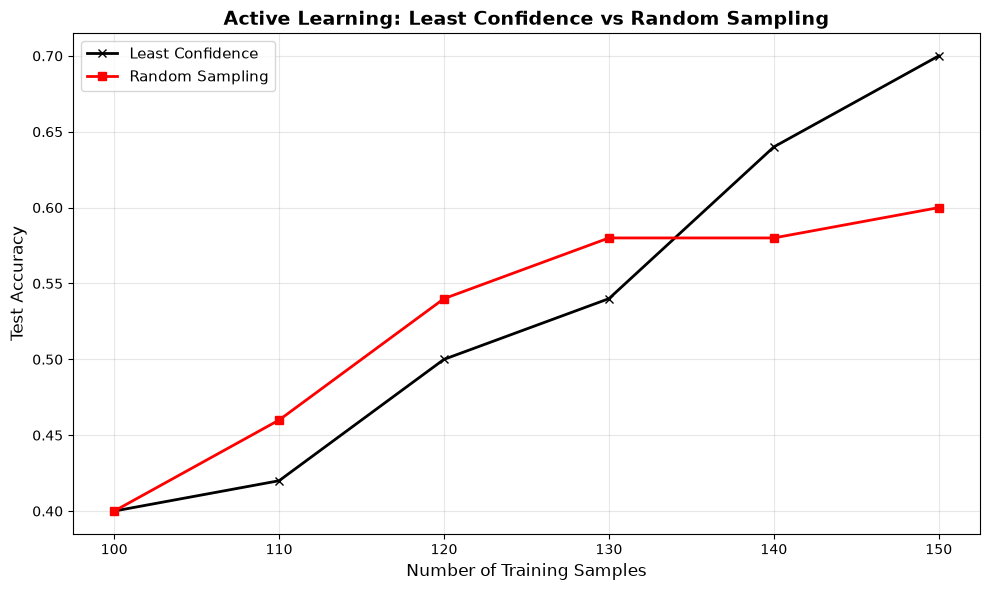


=== Final Results ===
Least Confidence - Final Accuracy: 0.7000 with 150 labels
Random Sampling - Final Accuracy: 0.6000 with 150 labels

Improvement: 0.1000 (16.67%)


In [16]:
# Run active learning with random sampling (baseline)
print("\n=== Random Sampling (Baseline) ===")
n_labels_random, accuracy_random = run_active_learning_loop(
    X_seed, y_seed, X_pool, y_pool, X_test, y_test,
    strategy_func=random_sampling,
    steps=5,
    batch_size=10
)

# Plot learning curves
plt.figure(figsize=(10, 6))
plt.plot(n_labels_lc, accuracy_lc, color = 'black', marker='x', label='Least Confidence', linewidth=2)
plt.plot(n_labels_random, accuracy_random, color = 'red', marker='s', label='Random Sampling', linewidth=2)
plt.xlabel('Number of Training Samples', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title('Active Learning: Least Confidence vs Random Sampling', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n=== Final Results ===")
print(f"Least Confidence - Final Accuracy: {accuracy_lc[-1]:.4f} with {n_labels_lc[-1]} labels")
print(f"Random Sampling - Final Accuracy: {accuracy_random[-1]:.4f} with {n_labels_random[-1]} labels")
print(f"\nImprovement: {(accuracy_lc[-1] - accuracy_random[-1]):.4f} ({(accuracy_lc[-1] - accuracy_random[-1])/accuracy_random[-1]*100:.2f}%)")

## Task 4: AI vs. AI (LLM & Noise Detection) (3 Marks)

**Objective:** Use LLMs for bulk labeling and detect hallucinations.

**Note:**

- Make an account at [open-router](https://openrouter.ai/) and get the API key.
- Use `google/gemini-2.5-flash-lite` (free tier) model as your LLM. Read the documentation on how to use it [here](https://openrouter.ai/google/gemini-2.5-flash-lite/api)
- Set environment variable using .env file and paste your API key in it.

### Part 4.1: LLM Pipeline with Few-Shot Prompting

Design a few-shot prompt with 3 examples from gold standard.
Send remaining unlabeled samples (~150) to Gemini API for labeling.

In [17]:
import os
import time
import json
import requests
import pandas as pd
from dotenv import load_dotenv

load_dotenv()
# Use provided API key or fall back to environment variable
API_KEY = os.environ.get("OPENROUTER_API_KEY")
SITE_URL = "http://localhost:8000"
SITE_NAME = "Student Lab Assignment"

MODEL_NAME = "google/gemini-2.5-flash-lite"

if not API_KEY:
    print("⚠ Warning: OPENROUTER_API_KEY not found. Please check your .env file.")
    print("For demonstration, we'll generate mock labels using simple rules.\n")
else:
    print("✓ API key configured. Using OpenRouter API for LLM labeling.\n")

def generate_few_shot_prompt(review_text, examples):
    """
    Constructs a few-shot prompt with 3 gold examples + target review.
    
    Args:
        review_text (str): The review to be labeled
        examples (list): List of 3 example dictionaries with 'review' and 'label' keys
    
    Returns:
        str: Formatted prompt string
    """
    prompt = "You are a sentiment analysis expert. Classify the following movie review as Positive, Negative, or Neutral.\n\n"
    prompt += "Here are some examples:\n\n"
    
    for i, ex in enumerate(examples, 1):
        prompt += f"Example {i}:\n"
        prompt += f"Review: {ex['review']}\n"
        prompt += f"Sentiment: {ex['label']}\n\n"
    
    prompt += "Now classify this review:\n"
    prompt += f"Review: {review_text}\n"
    prompt += "Sentiment (respond with only one word: Positive, Negative, or Neutral):"
    
    return prompt

def query_openrouter(review_text, examples):
    """
    Sends request to OpenRouter API with retry logic and parsing.
    
    Args:
        review_text (str): Review to classify
        examples (list): Few-shot examples (list of dicts with 'review' and 'label')
    
    Returns:
        str: Label ('Positive', 'Negative', or 'Neutral')
             Returns None if API fails or response is invalid
    
    Note:
        - Uses OpenRouter API endpoint: https://openrouter.ai/api/v1/chat/completions
        - Implements retry logic for rate limit errors (429)
        - Parses response from OpenRouter's chat completions format
    """
    url = "https://openrouter.ai/api/v1/chat/completions"
    
    headers = {
        "Authorization": f"Bearer {API_KEY}",
        "Content-Type": "application/json",
        "HTTP-Referer": SITE_URL,
        "X-Title": SITE_NAME
    }
    
    prompt = generate_few_shot_prompt(review_text, examples)

    payload = {
        "model": MODEL_NAME,
        "messages": [
            {"role": "user", "content": prompt}
        ],
        "temperature": 0.1,
        "max_tokens": 10
    }

    max_retries = 3
    for attempt in range(max_retries):
        try:
            response = requests.post(url, json=payload, headers=headers, timeout=30)
            
            if response.status_code == 429: 
                wait_time = 5 * (attempt + 1)
                print(f"Rate limited. Waiting {wait_time}s...")
                time.sleep(wait_time)
                continue
            
            if response.status_code == 200:
      
                data = response.json()
                content = data['choices'][0]['message']['content'].strip()
                
                content_upper = content.upper()
                if 'POSITIVE' in content_upper:
                    return 'Positive'
                elif 'NEGATIVE' in content_upper:
                    return 'Negative'
                elif 'NEUTRAL' in content_upper:
                    return 'Neutral'
                else:
                    print(f"Unexpected response: {content}")
                    return 'Neutral' 
            else:
                print(f"API error: {response.status_code} - {response.text}")
                return None
                
        except Exception as e:
            print(f"Request failed: {e}")
            if attempt < max_retries - 1:
                time.sleep(2)
    
    return None

gold_standard_df = pd.read_csv(csv_base_path / "gold_standard_100.csv")

few_shot_examples = []
for label in ['Positive', 'Negative', 'Neutral']:
    example = gold_standard_df[gold_standard_df['label'] == label].iloc[0]
    few_shot_examples.append({
        'review': example['review'],
        'label': example['label']
    })

print("Few-shot examples selected:")
for i, ex in enumerate(few_shot_examples, 1):
    print(f"{i}. {ex['label']}: {ex['review'][:60]}...")

all_reviews = pd.read_csv(csv_base_path / "movie_reviews_300.csv")


unlabeled_for_llm = all_reviews.iloc[100:250].reset_index(drop=True) 
print(f"\n{len(unlabeled_for_llm)} reviews to label with LLM\n")

llm_labels_list = []
for idx, row in unlabeled_for_llm.iterrows():
    print(f"Labeling review {idx+1}/{len(unlabeled_for_llm)}...")
    label = query_openrouter(row['review'], few_shot_examples)
        
    if label is None:
        label = 'Neutral' 
        
    llm_labels_list.append(label)
    print(f"  → {label}")

    if (idx + 1) % 10 == 0:
        print(f"Processed {idx+1} reviews. Pausing 5s...")
        time.sleep(5)
    else:
        time.sleep(0.5)  

llm_labeled_df = pd.DataFrame({
    'review': unlabeled_for_llm['review'],
    'label': llm_labels_list
})

print(f"\n=== LLM Labeling Complete ===")
print(f"Total labeled: {len(llm_labeled_df)}")
print(f"Label distribution:\n{llm_labeled_df['label'].value_counts()}")

llm_labels_path = csv_base_path / "llm_labels_150.csv"
llm_labeled_df.to_csv(llm_labels_path, index=False)


✓ API key configured. Using OpenRouter API for LLM labeling.

Few-shot examples selected:
1. Positive: This movie is a triumph in every sense. Highly recommended f...
2. Negative: I have never been so bored in my life. The score was frankly...
3. Neutral: Middle of the road entertainment. Visually it's fine, but th...

150 reviews to label with LLM

Labeling review 1/150...
  → Neutral
Labeling review 2/150...
  → Negative
Labeling review 3/150...
  → Negative
Labeling review 4/150...
  → Neutral
Labeling review 5/150...
  → Positive
Labeling review 6/150...
  → Positive
Labeling review 7/150...
  → Negative
Labeling review 8/150...
  → Neutral
Labeling review 9/150...
  → Positive
Labeling review 10/150...
  → Neutral
Processed 10 reviews. Pausing 5s...
Labeling review 11/150...
  → Neutral
Labeling review 12/150...
  → Neutral
Labeling review 13/150...
  → Positive
Labeling review 14/150...
  → Neutral
Labeling review 15/150...
  → Neutral
Labeling review 16/150...
  → Neutral
Labeli

### Part 4.2: Noise Hunting (Cleanlab Logic)

Train a Logistic Regression model on LLM-labeled data.
Identify "High Confidence Disagreements" where the model is very confident (>0.80) but disagrees with the LLM label.

In [18]:
def find_label_errors(llm_labels, model_probs, review_texts, threshold=0.90):
    """
    Detects high-confidence disagreements between model predictions and LLM labels.
    This implements Cleanlab logic: find cases where model is confident but disagrees with LLM.
    
    Args:
        llm_labels: List/array of labels from Gemini (numeric: 0=Negative, 1=Positive, 2=Neutral)
        model_probs: Probability matrix from Logistic Regression (shape: N_samples, N_classes)
        review_texts: List of review texts (for display)
        threshold: Confidence threshold (default 0.90)
    
    Returns:
        list: List of dictionaries with suspicious review information
              Each dict contains: 'index', 'text', 'llm_label', 'model_pred', 'confidence'
    """
    model_preds = np.argmax(model_probs, axis=1)

    model_confidences = np.max(model_probs, axis=1)

    label_mapping = {'Negative': 0, 'Positive': 1, 'Neutral': 2}
    if isinstance(llm_labels[0], str):
        llm_labels_numeric = np.array([label_mapping[label] for label in llm_labels])
    else:
        llm_labels_numeric = np.array(llm_labels)

    disagreement_mask = (model_preds != llm_labels_numeric) & (model_confidences > threshold)

    suspicious_reviews = []
    label_names = {0: 'Negative', 1: 'Positive', 2: 'Neutral'}
    
    for idx in np.where(disagreement_mask)[0]:
        suspicious_reviews.append({
            'index': idx,
            'text': review_texts[idx],
            'llm_label': label_names[llm_labels_numeric[idx]],
            'model_pred': label_names[model_preds[idx]],
            'confidence': model_confidences[idx]
        })

    suspicious_reviews.sort(key=lambda x: x['confidence'], reverse=True)
    
    return suspicious_reviews

print("=== Task 4.2: Noise Detection ===\n")

llm_df = pd.read_csv(csv_base_path / "llm_labels_150.csv")
print(f"Loaded {len(llm_df)} LLM-labeled reviews")

X_llm = vectorizer.transform(llm_df['review']).toarray()
print(f"Vectorized LLM reviews: {X_llm.shape}")

label_map = {'Negative': 0, 'Positive': 1, 'Neutral': 2}
y_llm = llm_df['label'].map(label_map).values
unique_classes = np.unique(y_llm)

print(f"\nLabel distribution:")
print(f"  Positive: {(y_llm == 1).sum()}")
print(f"  Negative: {(y_llm == 0).sum()}")
print(f"  Neutral: {(y_llm == 2).sum()}")
print(f"  Unique classes: {unique_classes}")

if len(unique_classes) < 2:
    print("\n⚠ Warning: LLM labels contain only one class. Cannot train a classifier.")
    print("This is expected if the mock labeling assigned all reviews to one category.")
    print("In a real scenario with diverse LLM labels, this wouldn't happen.")
else:
    print("\nTraining Logistic Regression on LLM-labeled data...")
    llm_model = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
    llm_model.fit(X_llm, y_llm)

    model_probs = llm_model.predict_proba(X_llm)
    print(f"Model probability shape: {model_probs.shape}")

    suspicious = find_label_errors(llm_df['label'].values, model_probs, llm_df['review'].values, threshold=0.80)
    
    print(f"\n=== Suspicious Labels Found ===")
    print(f"Total suspicious samples: {len(suspicious)}")

    num_to_show = min(5, len(suspicious))
    if num_to_show > 0:
        print(f"\nTop {num_to_show} most suspicious reviews:\n")
        for i, review in enumerate(suspicious[:num_to_show], 1):
            print(f"Example {i}:")
            print(f"Review: {review['text'][:100]}...")
            print(f"  LLM Label: {review['llm_label']}")
            print(f"  Model Prediction: {review['model_pred']}")
            print(f"  Model Confidence: {review['confidence']:.4f}")
            print()
    else:
        print("\n✓ No suspicious labels found! Model agrees with LLM on all high-confidence predictions.")
        print("This could mean:")
        print("  1. LLM labels are high quality")
        print("  2. Model learned the LLM's labeling patterns well")
        print("  3. Try lowering the confidence threshold to see disagreements")


=== Task 4.2: Noise Detection ===

Loaded 150 LLM-labeled reviews
Vectorized LLM reviews: (150, 288)

Label distribution:
  Positive: 38
  Negative: 43
  Neutral: 69
  Unique classes: [0 1 2]

Training Logistic Regression on LLM-labeled data...
Model probability shape: (150, 3)

=== Suspicious Labels Found ===
Total suspicious samples: 0

✓ No suspicious labels found! Model agrees with LLM on all high-confidence predictions.
This could mean:
  1. LLM labels are high quality
  2. Model learned the LLM's labeling patterns well
  3. Try lowering the confidence threshold to see disagreements


## Deliverables

**Submission Checklist:**
- [ ] Completed Jupyter Notebook with all tasks (Tasks 1-4)
- [ ] Include your label-studio annotation interface screenshot.
- [ ] gold_standard_100.csv
- [ ] weak_labels_200.csv
- [ ] llm_labels_150.json